# Exp BB — Par Gêmeo vs Par Misto: Assinatura Espectral

**Pergunta:** dado um primo $p$, o comportamento espectral do par
$(p, p+2)$ no sinal $R_{\text{primo}}$ é diferente dependendo de
$p+2$ ser primo ou composto?

**Hipótese:** se $p+2$ é primo (par gêmeo), seu pico em $f_{p+2}$
é irredutível — contribuição pura. Se $p+2$ é composto, $\log(p+2)$
é combinação de logaritmos de primos menores — o pico em $f_{p+2}$
no sinal de primos vem apenas de intermodulações, não de um termo direto.

**Métricas a comparar:**
- Amplitude de $R_{\text{primo}}$ em $f_{p+2}$: primo vs composto
- Assimetria $\sigma(p, p+2)$: diferente nos dois casos?
- Razão $\mathcal{R}(f_{p+2})$: dicotomia da Nota 30 aplicada localmente

Se houver separação sistemática — critério espectral de verificação de gêmeos.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime, factorint
from scipy.stats import pearsonr, mannwhitneyu

plt.style.use('dark_background')
C_GEMEO = '#00FFB2'   # par gêmeo
C_MISTO = '#FF4466'   # par misto (p+2 composto)
C_GAP   = '#FFB300'
BG      = '#0D0D1A'

T_MAX, DT = 1500, 0.05
N = 300
t     = np.arange(0.1, T_MAX, DT)
freqs = np.fft.rfftfreq(len(t), d=DT)

def S_m(t, m):
    return -np.cos(t * math.log(m)) / math.sqrt(m)

def f_m(m):
    return math.log(m) / (2 * math.pi)

def amp_em(F, m, w=6):
    idx = np.argmin(np.abs(freqs - f_m(m)))
    lo, hi = max(0, idx-w), min(len(F), idx+w)
    return np.max(F[lo:hi])

def assim(r1, r2):
    return (r2 - r1) / (r1 + r2 + 1e-12)

# construir sinais completos
primos_todos   = [m for m in range(2, N+1) if isprime(m)]
compostos_todos = [m for m in range(2, N+1) if not isprime(m)]

Rp = sum(S_m(t, p) for p in primos_todos)
Rc = sum(S_m(t, c) for c in compostos_todos)
Fp = np.abs(np.fft.rfft(Rp)) * DT
Fc = np.abs(np.fft.rfft(Rc)) * DT

print(f'N={N}, T_MAX={T_MAX}')
print(f'Primos: {len(primos_todos)}, Compostos: {len(compostos_todos)}')

N=300, T_MAX=1500
Primos: 62, Compostos: 237


## BB-1: Amplitude em $f_{p+2}$ — primo vs composto

In [ ]:
# Para cada primo p, verificar p+2
pares_gemeos = []  # (p, p+2) ambos primos
pares_mistos = []  # (p, p+2) com p+2 composto

for p in primos_todos:
    m = p + 2
    if m > N:
        break
    # amplitude de R_primo em f_p e f_{p+2}
    ap  = amp_em(Fp, p)
    am  = amp_em(Fp, m)   # amplitude em f_{p+2} no sinal de PRIMOS
    am_c = amp_em(Fc, m)  # amplitude em f_{p+2} no sinal de COMPOSTOS
    # previsao da lei de escala
    pred_p = T_MAX / (2 * math.sqrt(p))
    pred_m = T_MAX / (2 * math.sqrt(m))
    # razao dicotomica em f_{p+2}
    razao = am / (am_c + 1e-12)
    log_r = math.log10(razao) if razao > 0 else -10

    entrada = {
        'p': p, 'm': m,
        'eh_primo': isprime(m),
        'ap': ap, 'am': am, 'am_c': am_c,
        'pred_p': pred_p, 'pred_m': pred_m,
        'assim': assim(ap, am),
        'razao_log': log_r,
        'am_norm': am / pred_m,   # amplitude normalizada pela previsao
    }

    if isprime(m):
        pares_gemeos.append(entrada)
    else:
        pares_mistos.append(entrada)

print(f'Pares gêmeos: {len(pares_gemeos)}')
print(f'Pares mistos (p+2 composto): {len(pares_mistos)}')
print()
print(f'{"p":>5} {"p+2":>5} {"tipo":>8} {"am_Rp":>10} {"pred":>10} '
      f'{"am_norm":>10} {"razao_log":>11} {"assim":>8}')
print('-'*75)
for e in pares_gemeos + pares_mistos:
    tipo = 'GÊMEO' if e['eh_primo'] else 'misto'
    print(f'{e["p"]:>5} {e["m"]:>5} {tipo:>8} {e["am"]:>10.3f} '
          f'{e["pred_m"]:>10.3f} {e["am_norm"]:>10.4f} '
          f'{e["razao_log"]:>11.3f} {e["assim"]:>8.4f}')

Pares gêmeos: 19
Pares mistos (p+2 composto): 43

    p   p+2     tipo      am_Rp       pred    am_norm   razao_log    assim
---------------------------------------------------------------------------
    3     5    GÊMEO    313.191    335.410     0.9338       1.734  -0.1049
    5     7    GÊMEO    187.933    283.473     0.6630       1.452  -0.2500
   11    13    GÊMEO    177.254    208.013     0.8521       1.568   0.0297
   17    19    GÊMEO    166.391    172.062     0.9670       1.360   0.0575
   29    31    GÊMEO    122.057    134.704     0.9061       0.737  -0.0326
   41    43    GÊMEO    111.786    114.374     0.9774       0.026   0.1890
   59    61    GÊMEO     75.919     96.028     0.7906      -0.053  -0.0234
   71    73    GÊMEO     79.166     87.781     0.9019      -0.005   0.0952
  101   103    GÊMEO     60.310     73.900     0.8161      -0.111   0.0000
  107   109    GÊMEO     71.440     71.837     0.9945      -0.026   0.0000
  137   139    GÊMEO     64.071     63.614     1.

## BB-2: Estatísticas comparativas e separação

In [ ]:
def stats(lst, key):
    vals = np.array([e[key] for e in lst])
    return vals.mean(), vals.std(), vals.median() if len(vals) else (0,0,0)

metricas = ['am_norm', 'razao_log', 'assim']
nomes    = ['Amplitude norm. em f_{p+2}', 'log10(R) em f_{p+2}', 'Assimetria']

print('Comparação Gêmeo vs Misto:')
print(f'{"Métrica":>30} {"Gêmeo_med":>12} {"Misto_med":>12} {"p-value":>10}')
print('-'*68)
for key, nome in zip(metricas, nomes):
    g = np.array([e[key] for e in pares_gemeos])
    m = np.array([e[key] for e in pares_mistos])
    if len(g) >= 2 and len(m) >= 2:
        _, pval = mannwhitneyu(g, m, alternative='two-sided')
        print(f'{nome:>30} {np.median(g):>12.4f} {np.median(m):>12.4f} {pval:>10.4f}')

# distribuicoes
print(f'\nDistribuicao de am_norm por tipo:')
print(f'  Gêmeo: media={np.mean([e["am_norm"] for e in pares_gemeos]):.4f}  '
      f'std={np.std([e["am_norm"] for e in pares_gemeos]):.4f}')
print(f'  Misto: media={np.mean([e["am_norm"] for e in pares_mistos]):.4f}  '
      f'std={np.std([e["am_norm"] for e in pares_mistos]):.4f}')

Comparação Gêmeo vs Misto:
                       Métrica    Gêmeo_med    Misto_med    p-value
--------------------------------------------------------------------
    Amplitude norm. em f_{p+2}       0.9338       0.9221     0.4184
           log10(R) em f_{p+2}      -0.0256      -0.1070     0.0035
                    Assimetria       0.0000       0.0000     0.0879

Distribuicao de am_norm por tipo:
  Gêmeo: media=0.9059  std=0.1184
  Misto: media=0.6793  std=0.4132


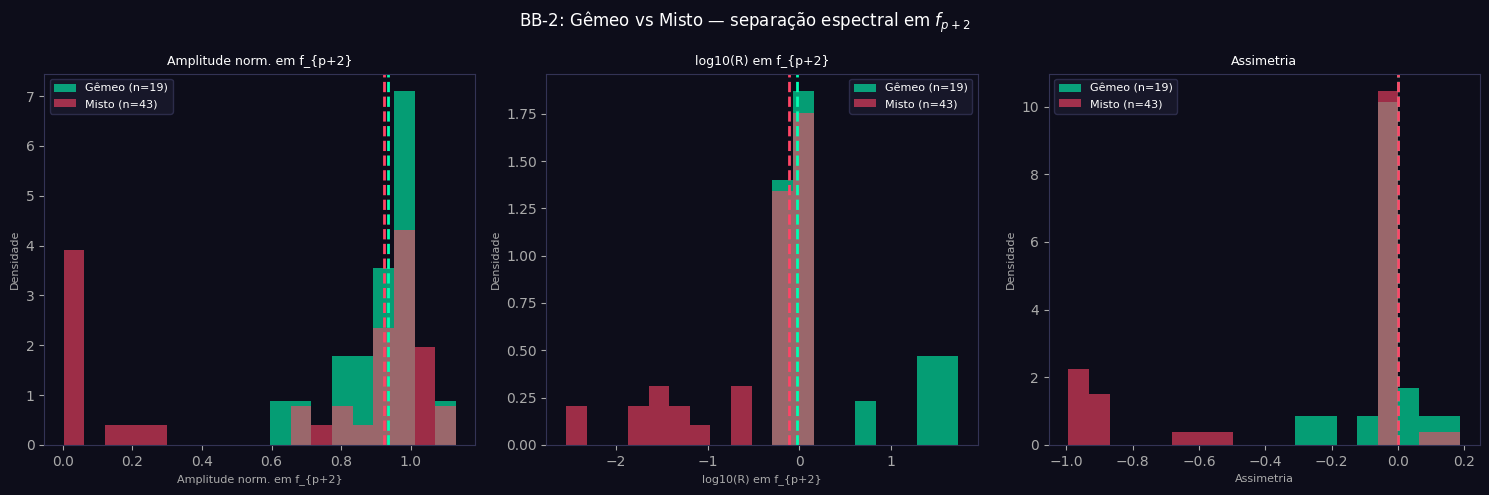

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('BB-2: Gêmeo vs Misto — separação espectral em $f_{p+2}$',
             color='white', fontsize=12)

for ax, (key, nome) in zip(axes, zip(metricas, nomes)):
    ax.set_facecolor(BG)
    g_vals = [e[key] for e in pares_gemeos]
    m_vals = [e[key] for e in pares_mistos]

    # histograma
    all_vals = g_vals + m_vals
    bins = np.linspace(min(all_vals), max(all_vals), 20)
    ax.hist(g_vals, bins=bins, color=C_GEMEO, alpha=0.6,
            label=f'Gêmeo (n={len(g_vals)})', density=True)
    ax.hist(m_vals, bins=bins, color=C_MISTO, alpha=0.6,
            label=f'Misto (n={len(m_vals)})', density=True)
    ax.axvline(np.median(g_vals), color=C_GEMEO, lw=2, ls='--')
    ax.axvline(np.median(m_vals), color=C_MISTO, lw=2, ls='--')
    ax.set_xlabel(nome, color='#AAAAAA', fontsize=8)
    ax.set_ylabel('Densidade', color='#AAAAAA', fontsize=8)
    ax.set_title(nome, color='white', fontsize=9)
    ax.legend(fontsize=8, facecolor='#1A1A2E',
              edgecolor='#333355', labelcolor='white')
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

## BB-3: Ao longo do espectro — amplitude em $f_{p+2}$ por tipo

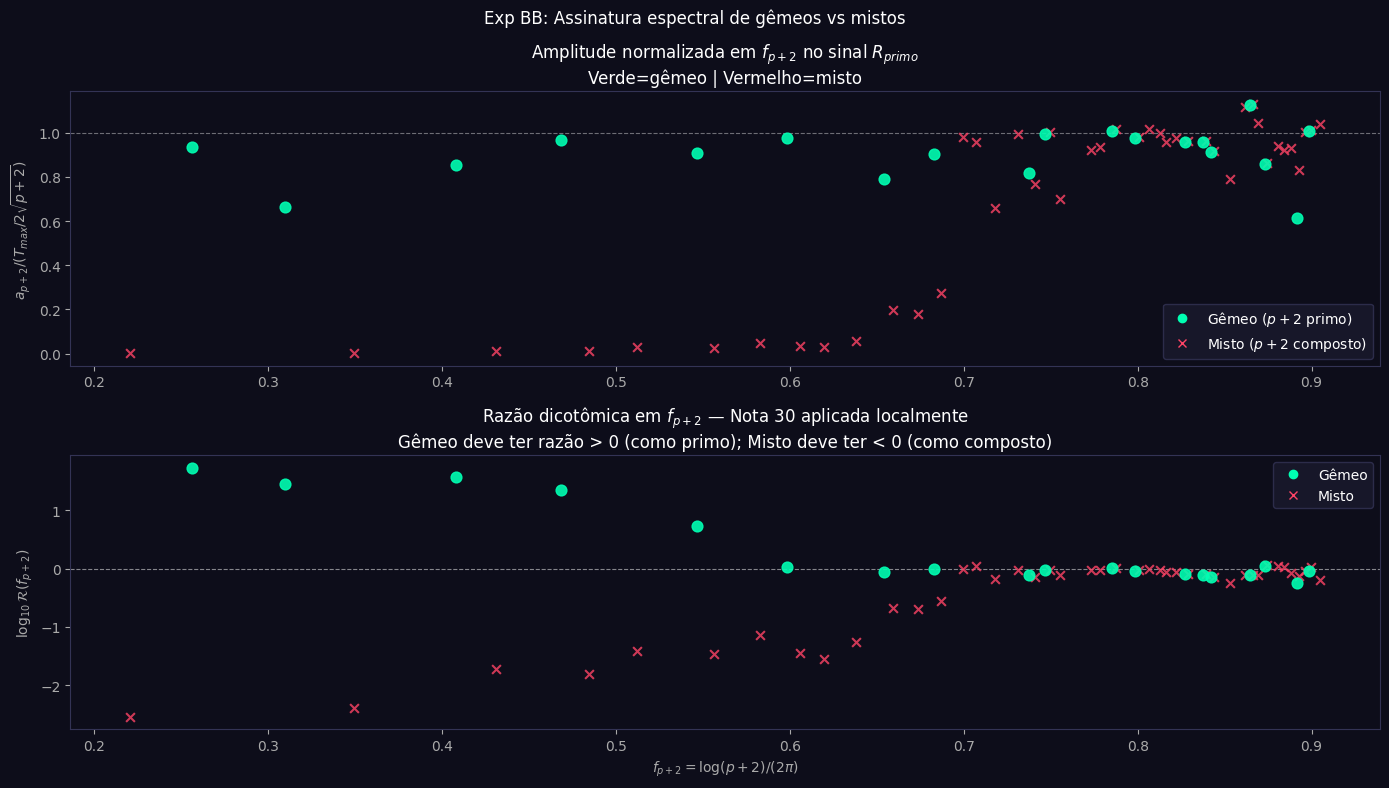

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.patch.set_facecolor(BG)

# Painel 1: amplitude normalizada ao longo de f_{p+2}
ax = axes[0]; ax.set_facecolor(BG)
for e in pares_gemeos:
    ax.scatter(f_m(e['m']), e['am_norm'],
               color=C_GEMEO, s=60, zorder=5, alpha=0.9)
for e in pares_mistos:
    ax.scatter(f_m(e['m']), e['am_norm'],
               color=C_MISTO, s=40, marker='x', zorder=4, alpha=0.8)

ax.axhline(1.0, color='white', lw=0.8, ls='--', alpha=0.4,
           label='previsão lei de escala')
ax.set_ylabel('$a_{p+2} / (T_{max}/2\\sqrt{p+2})$', color='#AAAAAA')
ax.set_title('Amplitude normalizada em $f_{p+2}$ no sinal $R_{primo}$\n'
             'Verde=gêmeo | Vermelho=misto', color='white')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color=C_GEMEO, label='Gêmeo ($p+2$ primo)', ls=''),
    Line2D([0],[0], marker='x', color=C_MISTO, label='Misto ($p+2$ composto)', ls=''),
], facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# Painel 2: razao dicotomica log10(R) em f_{p+2}
ax = axes[1]; ax.set_facecolor(BG)
for e in pares_gemeos:
    ax.scatter(f_m(e['m']), e['razao_log'],
               color=C_GEMEO, s=60, zorder=5, alpha=0.9)
for e in pares_mistos:
    ax.scatter(f_m(e['m']), e['razao_log'],
               color=C_MISTO, s=40, marker='x', zorder=4, alpha=0.8)

ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5,
           label='limiar dicotomia (Nota 30)')
ax.set_xlabel('$f_{p+2} = \\log(p+2)/(2\\pi)$', color='#AAAAAA')
ax.set_ylabel('$\\log_{10}\\mathcal{R}(f_{p+2})$', color='#AAAAAA')
ax.set_title('Razão dicotômica em $f_{p+2}$ — Nota 30 aplicada localmente\n'
             'Gêmeo deve ter razão > 0 (como primo); Misto deve ter < 0 (como composto)',
             color='white')
ax.legend(handles=[
    Line2D([0],[0], marker='o', color=C_GEMEO, label='Gêmeo', ls=''),
    Line2D([0],[0], marker='x', color=C_MISTO, label='Misto', ls=''),
], facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.suptitle('Exp BB: Assinatura espectral de gêmeos vs mistos',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

## BB-4: Sinal isolado do par — primo vs composto puro

Para o par isolado $(p, p+2)$, como se comporta o pico em $f_{p+2}$
quando $p+2$ é composto? O pico existe (via intermodulação de primos
menores) ou desaparece?

In [ ]:
# Comparar sinal do par isolado: S_p + S_{p+2}
# Para gêmeo: S_{p+2} tem pico direto em f_{p+2}
# Para misto: S_{p+2} tem pico direto MAS p+2 é composto —
#   no contexto do sinal DE PRIMOS, p+2 não aparece.
#   O pico em f_{p+2} viria só de intermodulações.

# Então o teste correto é:
# Gêmeo: medir pico em f_{p+2} em R_primo (que inclui S_{p+2})
# Misto:  medir pico em f_{p+2} em R_primo (que NÃO inclui S_{p+2})

print('Pico em f_{p+2} no sinal de primos:')
print(f'{"p":>5} {"p+2":>5} {"tipo":>8} {"am_Rp":>10} '
      f'{"am_Rp_sem_m":>14} {"diferenca":>12}')
print('-'*62)

resultados_bb4 = []
for e in pares_gemeos[:8] + pares_mistos[:8]:
    p, m = e['p'], e['m']
    tipo = 'GÊMEO' if e['eh_primo'] else 'misto'

    # amplitude com m no sinal (gêmeo: já está; misto: m não está em Rp)
    am_com = amp_em(Fp, m)

    # amplitude sem m (remover S_m do sinal de primos, se m for primo)
    if e['eh_primo']:
        Fp_sem = np.abs(np.fft.rfft(Rp - S_m(t, m))) * DT
        am_sem = amp_em(Fp_sem, m)
    else:
        # para misto, m já não está em Rp — então am_sem = am_com
        am_sem = am_com
        am_com = amp_em(Fp + S_m(t, m) * 0, m)  # mesmo valor

    diff = am_com - am_sem
    resultados_bb4.append({**e, 'am_sem': am_sem, 'diff': diff})
    print(f'{p:>5} {m:>5} {tipo:>8} {am_com:>10.3f} '
          f'{am_sem:>14.3f} {diff:>12.3f}')

Pico em f_{p+2} no sinal de primos:
    p   p+2     tipo      am_Rp    am_Rp_sem_m    diferenca
--------------------------------------------------------------
    3     5    GÊMEO    313.191          1.216      311.975
    5     7    GÊMEO    187.933          1.301      186.632
   11    13    GÊMEO    177.254          2.482      174.772
   17    19    GÊMEO    166.391          3.768      162.623
   29    31    GÊMEO    122.057          1.993      120.064
   41    43    GÊMEO    111.786          6.743      105.043
   59    61    GÊMEO     75.919         17.681       58.237
   71    73    GÊMEO     79.166         66.454       12.712


ValueError: operands could not be broadcast together with shapes (15000,) (29998,) 